In [1]:


import importlib

import pandas as pd
import numpy as np
#import scanpy as sc
#import scycle as cc
# import scvelo as sv
#import anndata
from sklearn.decomposition import PCA

import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [6]:
pwd

'/home/karen/Documents/GitHub/muscleCellAtlas'

In [16]:
expression_df= pd.read_csv("results/mean_expression_cell.csv", index_col = 0)

In [57]:
expression_df=expression_df.drop_duplicates()

In [20]:
expression_df.drop(columns=["most abundant in"],inplace=True)
expression_df.head()

,Adipocyte,ArtEC,B-cell,B-plasma,CapEC,EnFB,Eosinophil,FB,Hyb,LymphEC,...,SMC,Specialised MF,T-cell,Tenocyte,VenEC,cDC1,cDC2,mSchwann,nmSchwann,pDC
Gene,,,,,,,,,,,,,,,,,,,,,
ACIN1,0.417506,0.209104,0.147946,0.207114,0.188800,0.174024,0.315649,0.232859,0.249706,0.180436,...,0.196829,0.210590,0.222980,0.250792,0.203175,0.320608,0.223156,0.129569,0.169012,0.330829
ADA,0.014123,0.149343,0.051087,0.211794,0.271267,0.036564,0.021994,0.183599,0.001473,0.029182,...,0.011903,0.006037,0.082023,0.030694,0.072762,0.097412,0.110402,0.007948,0.024961,0.593198
AK1,0.033758,0.077454,0.004963,0.015381,0.046405,0.089141,0.000000,0.067482,0.057971,0.310814,...,0.169288,0.095611,0.014278,0.068266,0.093459,0.022601,0.005838,0.098941,0.095709,0.000000
ALDOA,0.000000,0.170275,0.072773,0.188611,0.208669,0.151496,0.031045,0.130680,0.000000,0.230462,...,0.433692,0.146612,0.118930,0.085669,0.220126,0.188399,0.213363,0.175072,0.075162,0.110334
AS3MT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001418,...,0.000158,0.000367,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


To test whether the gene expression values across cell types are normally distributed, you can use the Shapiro-Wilk test or Anderson-Darling test:

In [21]:
from scipy.stats import shapiro

# Transpose so we test normality across cell types per gene
normality_results = {}

for gene in expression_df.index:
    stat, p = shapiro(expression_df.loc[gene, :])  # Test normality across cell types
    normality_results[gene] = p

# Convert to DataFrame
normality_df = pd.DataFrame.from_dict(normality_results, orient="index", columns=["p_value"])

# Check how many genes have p < 0.05 (reject normality)
non_normal_genes = normality_df[normality_df["p_value"] < 0.05]
print(f"Non-normal genes: {len(non_normal_genes)} out of {len(expression_df)}")

Non-normal genes: 37 out of 44


In [25]:
normality_df[normality_df["p_value"]>= 0.05].index

Index(['CCNI', 'ERI3', 'NDUFB4', 'PARK7', 'RECQL', 'RNF7', 'SBDS'], dtype='object')

In [29]:
expression_df.loc[gene, :].values

array([0.41750562, 0.20910382, 0.14794606, 0.20711368, 0.18879959,
       0.17402385, 0.3156489 , 0.23285876, 0.24970587, 0.18043593,
       0.19212498, 0.17454025, 0.15793726, 0.15666783, 0.11396395,
       0.1315889 , 0.31332844, 0.1419269 , 0.19890329, 0.20265177,
       0.19427451, 0.25661045, 0.08749327, 0.15671861, 0.15370886,
       0.12510383, 0.19682868, 0.21059   , 0.22298029, 0.2507922 ,
       0.20317456, 0.3206083 , 0.22315595, 0.12956937, 0.16901158,
       0.3308291 ])

To determine if a gene is significantly overexpressed in a specific cell type:

One-way ANOVA (if normality holds) or Kruskal-Wallis test (if non-normal).
Post-hoc tests to find which cell types differ.
ANOVA (if normal)
python
Copy
Edit


In [37]:
from scipy.stats import f_oneway

anova_results = {}

p = f_oneway(*expression_df.iloc[:, :].values)

p

F_onewayResult(statistic=39.32410040115358, pvalue=5.0779577215860244e-214)

we can use Tukey's HSD test (for normal data) or Dunn’s test (for non-normal) to identify which cell types differ.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# Reshape data for Tukey's test
melted_df = expression_df.reset_index().melt(id_vars="Gene", var_name="CellType", value_name="Expression")

tukey_results = pairwise_tukeyhsd(melted_df["Expression"], melted_df["CellType"])
print(tukey_results)


In [59]:
tukey_results_df = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
len(tukey_results_df)

630

In [60]:
len(tukey_results_df['group1'].unique())

35

In [61]:
len(tukey_results_df[tukey_results_df['reject']==False])

602

In [56]:
tukey_results_df[tukey_results_df['reject']==False].head()

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Adipocyte,ArtEC,0.1565,1.0,-0.4652,0.7782,False
1,Adipocyte,B-cell,0.1235,1.0,-0.4982,0.7452,False
2,Adipocyte,B-plasma,0.0790,1.0,-0.5427,0.7007,False
3,Adipocyte,CapEC,0.1509,1.0,-0.4708,0.7726,False
4,Adipocyte,EnFB,0.1288,1.0,-0.4929,0.7505,False


In [68]:
significant_tukey = tukey_results_df[tukey_results_df['reject']==True]
len(significant_tukey)

28

In [78]:
significant_tukey[significant_tukey['group1']!='MF-Isc(fg)']

,group1,group2,meandiff,p-adj,lower,upper,reject
13,Adipocyte,MF-Isc(fg),0.8358,0.0002,0.2142,1.4575,True
47,ArtEC,MF-Isc(fg),0.6793,0.0133,0.0577,1.3010,True
80,B-cell,MF-Isc(fg),0.7123,0.0058,0.0907,1.3340,True
112,B-plasma,MF-Isc(fg),0.7569,0.0017,0.1352,1.3786,True
143,CapEC,MF-Isc(fg),0.6849,0.0116,0.0632,1.3066,True
173,EnFB,MF-Isc(fg),0.7071,0.0066,0.0854,1.3287,True
202,Eosinophil,MF-Isc(fg),0.6925,0.0096,0.0708,1.3142,True
230,FB,MF-Isc(fg),0.7112,0.0059,0.0895,1.3328,True
257,Hyb,MF-Isc(fg),0.7258,0.0040,0.1041,1.3475,True
308,MF-I,MF-Isc(fg),0.7073,0.0066,0.0857,1.3290,True


In [74]:
len(significant_tukey[significant_tukey['group1']=='MF-Isc(fg)'])

16

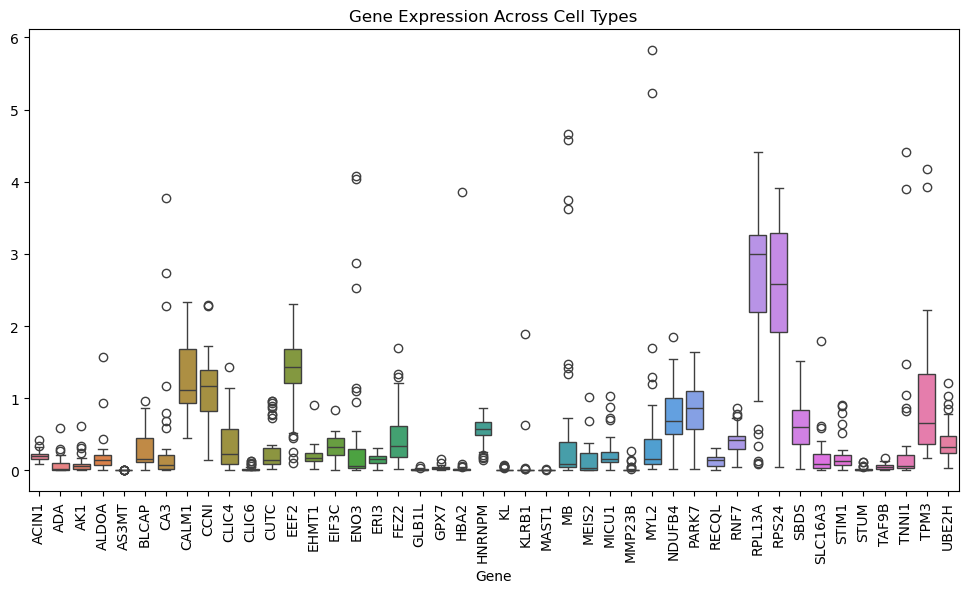

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=expression_df.T)
plt.xticks(rotation=90)
plt.title("Gene Expression Across Cell Types")
plt.savefig('results/GeneExpressionAcrossCellType.png')
plt.show()

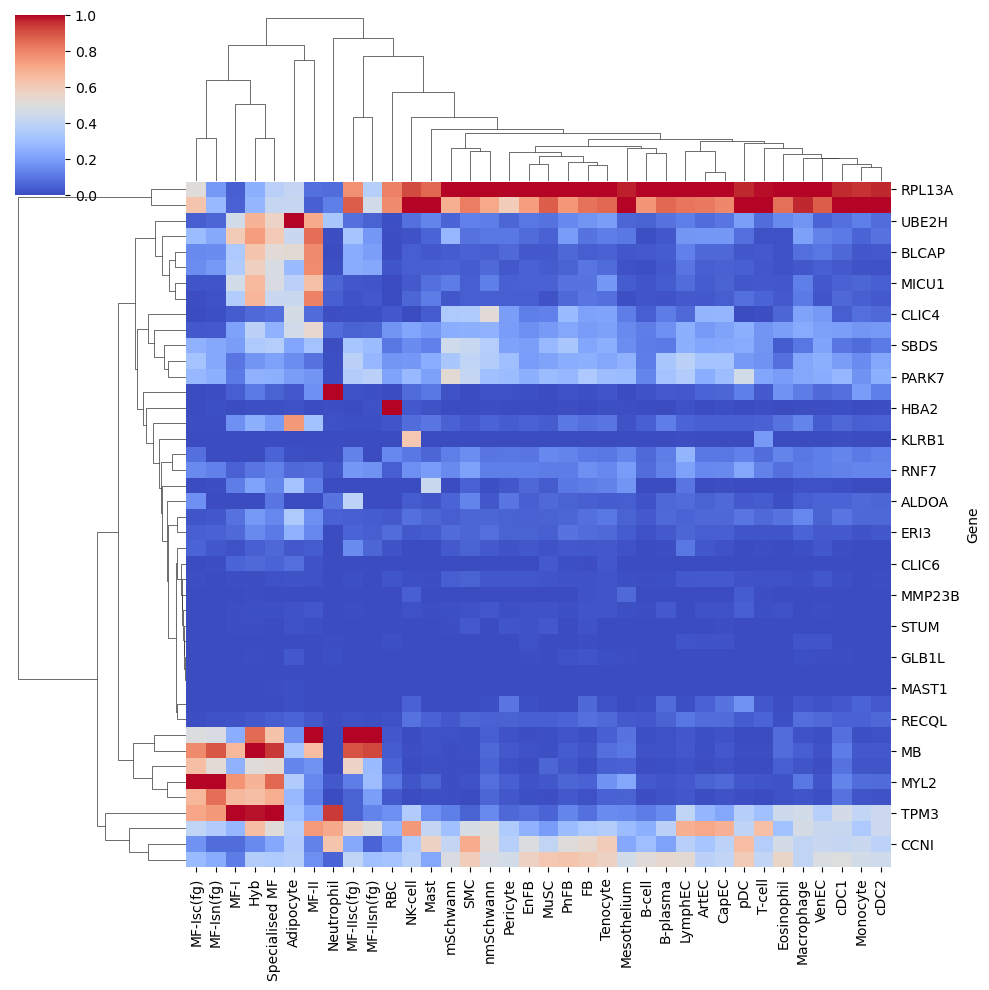

In [80]:
sns.clustermap(expression_df, cmap="coolwarm", standard_scale=1)
plt.savefig('results/heatmap_expressionCell_per_gene.png')
plt.show()

<Figure size 1500x2000 with 0 Axes>

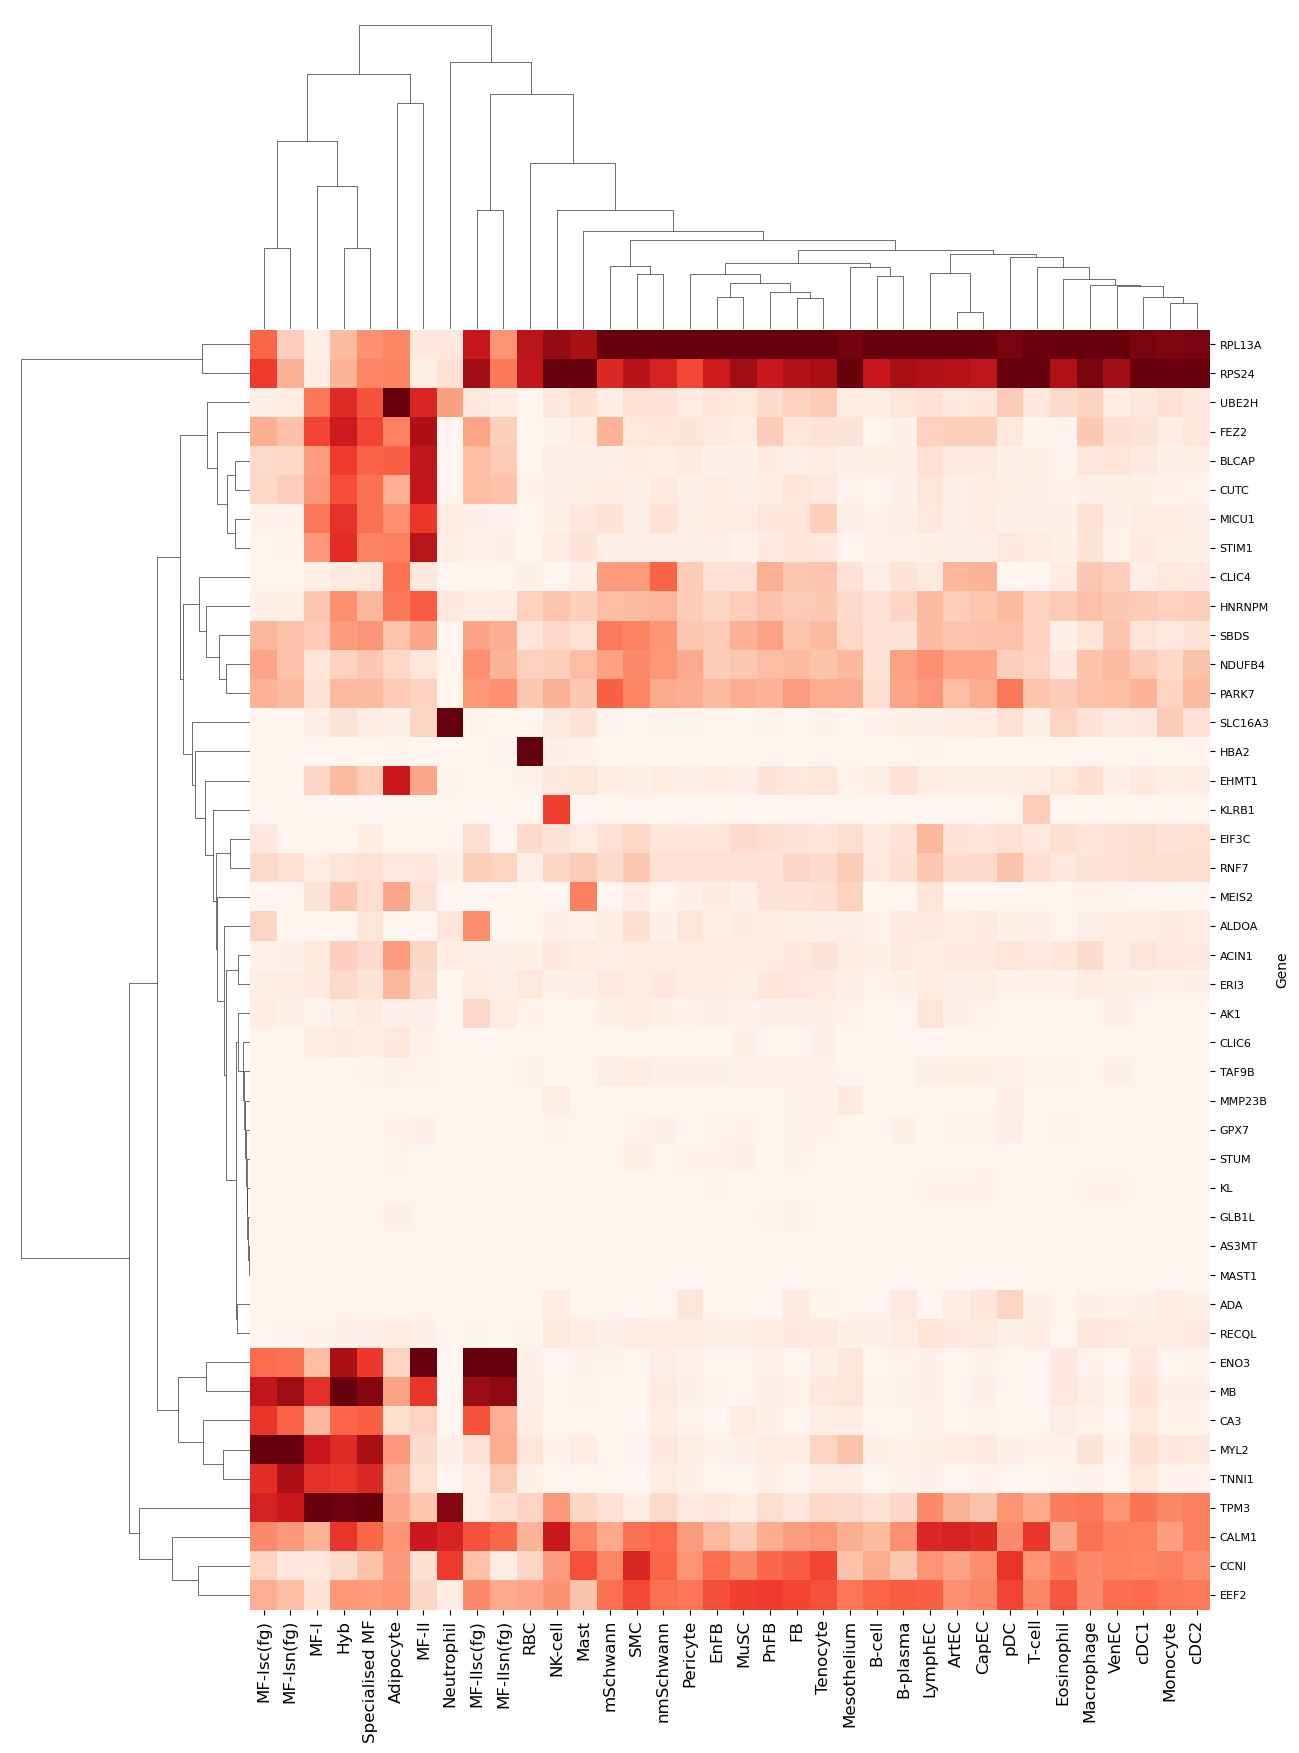

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Increase figure size to fit all labels
plt.figure(figsize=(15, 20))  # Adjust width (x) and height (y) accordingly

g = sns.clustermap(expression_df, cmap="Reds", standard_scale=1, figsize=(15, 20), cbar_pos=None)

# Adjust x-axis (cell type) labels
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=12)

# Adjust y-axis (gene) labels
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)  # Reduce font if needed

# Ensure labels don't get cut off
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  
plt.savefig('results/heatmap_expressionCell_per_gene.png')

plt.show()


In [43]:
expression_df=expression_df.drop_duplicates()

In [45]:
reshaped_df = expression_df.pivot(index="Gene", columns="Cell Type", values="Mean Expression")

# Optionally, sort the index and columns for better organization
reshaped_df = reshaped_df.sort_index().sort_index(axis=1)

In [48]:
reshaped_df["most abundant in"] = reshaped_df.idxmax(axis=1)


In [51]:
reshaped_df["most abundant in"]

Gene
ACIN1        Adipocyte
ADA                pDC
AK1        MF-IIsc(fg)
ALDOA      MF-IIsc(fg)
AS3MT      Mesothelium
BLCAP      MF-IIsc(fg)
CA3         MF-Isc(fg)
CALM1       MF-Isc(fg)
CCNI               SMC
CLIC4        nmSchwann
CLIC6             MF-I
CUTC        MF-Isn(fg)
EEF2              MuSC
EHMT1        Adipocyte
EIF3C          LymphEC
ENO3       MF-IIsn(fg)
ERI3         Adipocyte
FEZ2        MF-Isc(fg)
GLB1L               FB
GPX7               pDC
HBA2               RBC
HNRNPM             pDC
KL               VenEC
KLRB1          NK-cell
MAST1        Adipocyte
MB          MF-Isn(fg)
MEIS2             Mast
MICU1             MF-I
MMP23B     Mesothelium
MYL2        MF-Isc(fg)
NDUFB4      MF-Isc(fg)
PARK7         mSchwann
RECQL          LymphEC
RNF7        MF-Isc(fg)
RPL13A          B-cell
RPS24      Mesothelium
SBDS        MF-Isc(fg)
SLC16A3     Neutrophil
STIM1              Hyb
STUM              MuSC
TAF9B              SMC
TNNI1       MF-Isn(fg)
TPM3        MF-Isc(fg)
UBE2H 

In [52]:
reshaped_df.to_csv("results/mean_expression_cell.csv")

In [55]:
proportion_df = pd.DataFrame.from_dict(cell_type_proportions, orient="index", columns=["Proportion"])

# Reset the index to make the cell type a column (optional)
proportion_df = proportion_df.reset_index().rename(columns={"index": "Cell Type"})
proportion_df = proportion_df.set_index("Cell Type")

In [57]:
proportion_df.to_csv("results/proportion_cell_type.csv")